<a href="https://colab.research.google.com/github/juniperlovato/Taste_for_Privacy_Facct/blob/main/1_Taste4Privacy_privacysettingsonsocialmedia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [38]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10

# Data

In [39]:
# read in dataframe
df_all = pd.read_csv('/filepath.csv')

# Taste for privacy by privacy settings

In [40]:
#show pecentages df_all['TP_Social']
df_all['TP_Social'].value_counts(normalize=True) * 100

,proportion
TP_Social,
3.0,62.042738
2.0,21.586382
1.0,16.370880


In [41]:
#show pecentages of TP_Month_numeric
df_all['TP_Month_numeric'].value_counts(normalize=True) * 100

,proportion
TP_Month_numeric,
8.0,77.620602
7.0,14.689880
6.0,3.155604
1.0,1.849837
5.0,1.015597
4.0,0.761697
2.0,0.507798
3.0,0.398984


In [42]:
#show pecentages of TP_Platform
df_all['TP_Platform'].value_counts(normalize=True) * 100

,proportion
TP_Platform,
5.0,21.879536
6.0,20.754717
4.0,20.718433
7.0,14.658926
3.0,12.409289
2.0,7.656023
1.0,1.923077


In [43]:
#pecentages of all these columns
df_all[['TP_Platforms_twitter', 'TP_Platforms_instagram', 'TP_Platforms_facebook', 'TP_Platforms_tiktok', 'TP_Platforms_other']].sum() / len(df_all) * 100


,0
TP_Platforms_twitter,14.389234
TP_Platforms_instagram,86.024845
TP_Platforms_facebook,12.629400
TP_Platforms_tiktok,61.214631
TP_Platforms_other,33.988958


In [51]:
# Create descriptive statistics table
desc_stats = []

# Privacy Settings (TP_Social)
privacy_counts = df_all['TP_Social'].value_counts().sort_index()
privacy_pcts = df_all['TP_Social'].value_counts(normalize=True).sort_index() * 100

desc_stats.append({
    'Variable': 'Privacy Settings',
    'Category/Statistic': 'Public (1)',
    'N': privacy_counts.get(1, 0),
    'Percent': f"{privacy_pcts.get(1, 0):.1f}%",
    'Mean (SD)': ''
})
desc_stats.append({
    'Variable': '',
    'Category/Statistic': 'Mixed (2)',
    'N': privacy_counts.get(2, 0),
    'Percent': f"{privacy_pcts.get(2, 0):.1f}%",
    'Mean (SD)': ''
})
desc_stats.append({
    'Variable': '',
    'Category/Statistic': 'Private (3)',
    'N': privacy_counts.get(3, 0),
    'Percent': f"{privacy_pcts.get(3, 0):.1f}%",
    'Mean (SD)': ''
})

# Social Media Use (TP_Month_numeric)
sm_use_mean = df_all['TP_Month_numeric'].mean()
sm_use_sd = df_all['TP_Month_numeric'].std()
sm_use_n = df_all['TP_Month_numeric'].notna().sum()

desc_stats.append({
    'Variable': 'Social Media Use (typical per month)',
    'Category/Statistic': '',
    'N': sm_use_n,
    'Percent': '',
    'Mean (SD)': f"{sm_use_mean:.2f} ({sm_use_sd:.2f})"
})

# Number of Platforms Used
platform_cols = ['TP_Platforms_twitter', 'TP_Platforms_instagram',
                 'TP_Platforms_facebook', 'TP_Platforms_tiktok',
                 'TP_Platforms_other']

# Calculate number of platforms per person
df_all['n_platforms'] = df_all[platform_cols].sum(axis=1)
platform_mean = df_all['n_platforms'].mean()
platform_sd = df_all['n_platforms'].std()
platform_n = df_all['n_platforms'].notna().sum()

desc_stats.append({
    'Variable': 'Number of Platforms Used',
    'Category/Statistic': '',
    'N': platform_n,
    'Percent': '',
    'Mean (SD)': f"{platform_mean:.2f} ({platform_sd:.2f})"
})

# Individual Platform Usage
platform_names = {
    'TP_Platforms_twitter': 'Twitter/X',
    'TP_Platforms_instagram': 'Instagram',
    'TP_Platforms_facebook': 'Facebook',
    'TP_Platforms_tiktok': 'TikTok',
    'TP_Platforms_other': 'Other'
}

desc_stats.append({
    'Variable': 'Platform Usage',
    'Category/Statistic': '',
    'N': '',
    'Percent': '',
    'Mean (SD)': ''
})

for col, name in platform_names.items():
    platform_users = df_all[col].sum()
    platform_pct = (df_all[col].sum() / len(df_all)) * 100

    desc_stats.append({
        'Variable': '',
        'Category/Statistic': f'  {name}',
        'N': int(platform_users),
        'Percent': f"{platform_pct:.1f}%",
        'Mean (SD)': ''
    })

# Create DataFrame
desc_table = pd.DataFrame(desc_stats)

##settings by how comfortable they are sharing data with social media platform

In [45]:
d = df_all[["TP_Social", "TP_Platform"]].dropna().copy()

mod = OrderedModel(
    endog=d["TP_Social"],
    exog=d[["TP_Platform"]],
    distr="logit"
)
res = mod.fit(method="bfgs", disp=False)
print(res.summary())

# odds ratio (per +1 step more uncomfortable)
beta = res.params["TP_Platform"]
OR = float(np.exp(beta))
ci_lo, ci_hi = np.exp(res.conf_int().loc["TP_Platform"])
print(f"\nOR per +1 discomfort step = {OR:.2f} (95% CI {ci_lo:.2f}-{ci_hi:.2f})")

                             OrderedModel Results                             
Dep. Variable:              TP_Social   Log-Likelihood:                -2462.1
Model:                   OrderedModel   AIC:                             4930.
Method:            Maximum Likelihood   BIC:                             4948.
Date:                Sat, 09 May 2026                                         
Time:                        13:11:43                                         
No. Observations:                2751                                         
Df Residuals:                    2748                                         
Df Model:                           1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
TP_Platform     0.3108      0.025     12.217      0.000       0.261       0.361
1.0/2.0        -0.2307      0.122     -1.886     

###histograms of the likert scales of comfort sharing with social media platforms by privacy settings


In [52]:
# Clean data - keep only valid responses
df_clean = df_all[['TP_Platform', 'TP_Social']].dropna().copy()
df_clean = df_clean[
    (df_clean['TP_Platform'].between(1, 7)) &
    (df_clean['TP_Social'].isin([1, 2, 3]))
].copy()

df_clean['TP_Platform'] = df_clean['TP_Platform'].astype(int)
df_clean['TP_Social'] = df_clean['TP_Social'].astype(int)

# Create Likert groups (binning 1-7 into 3 groups)
df_clean['Likert_Group'] = pd.cut(
    df_clean['TP_Platform'],
    bins=[0, 2, 5, 7],
    labels=['Low Discomfort (1-2)', 'Medium Discomfort (3-5)', 'High Discomfort (6-7)'],
    include_lowest=True
)

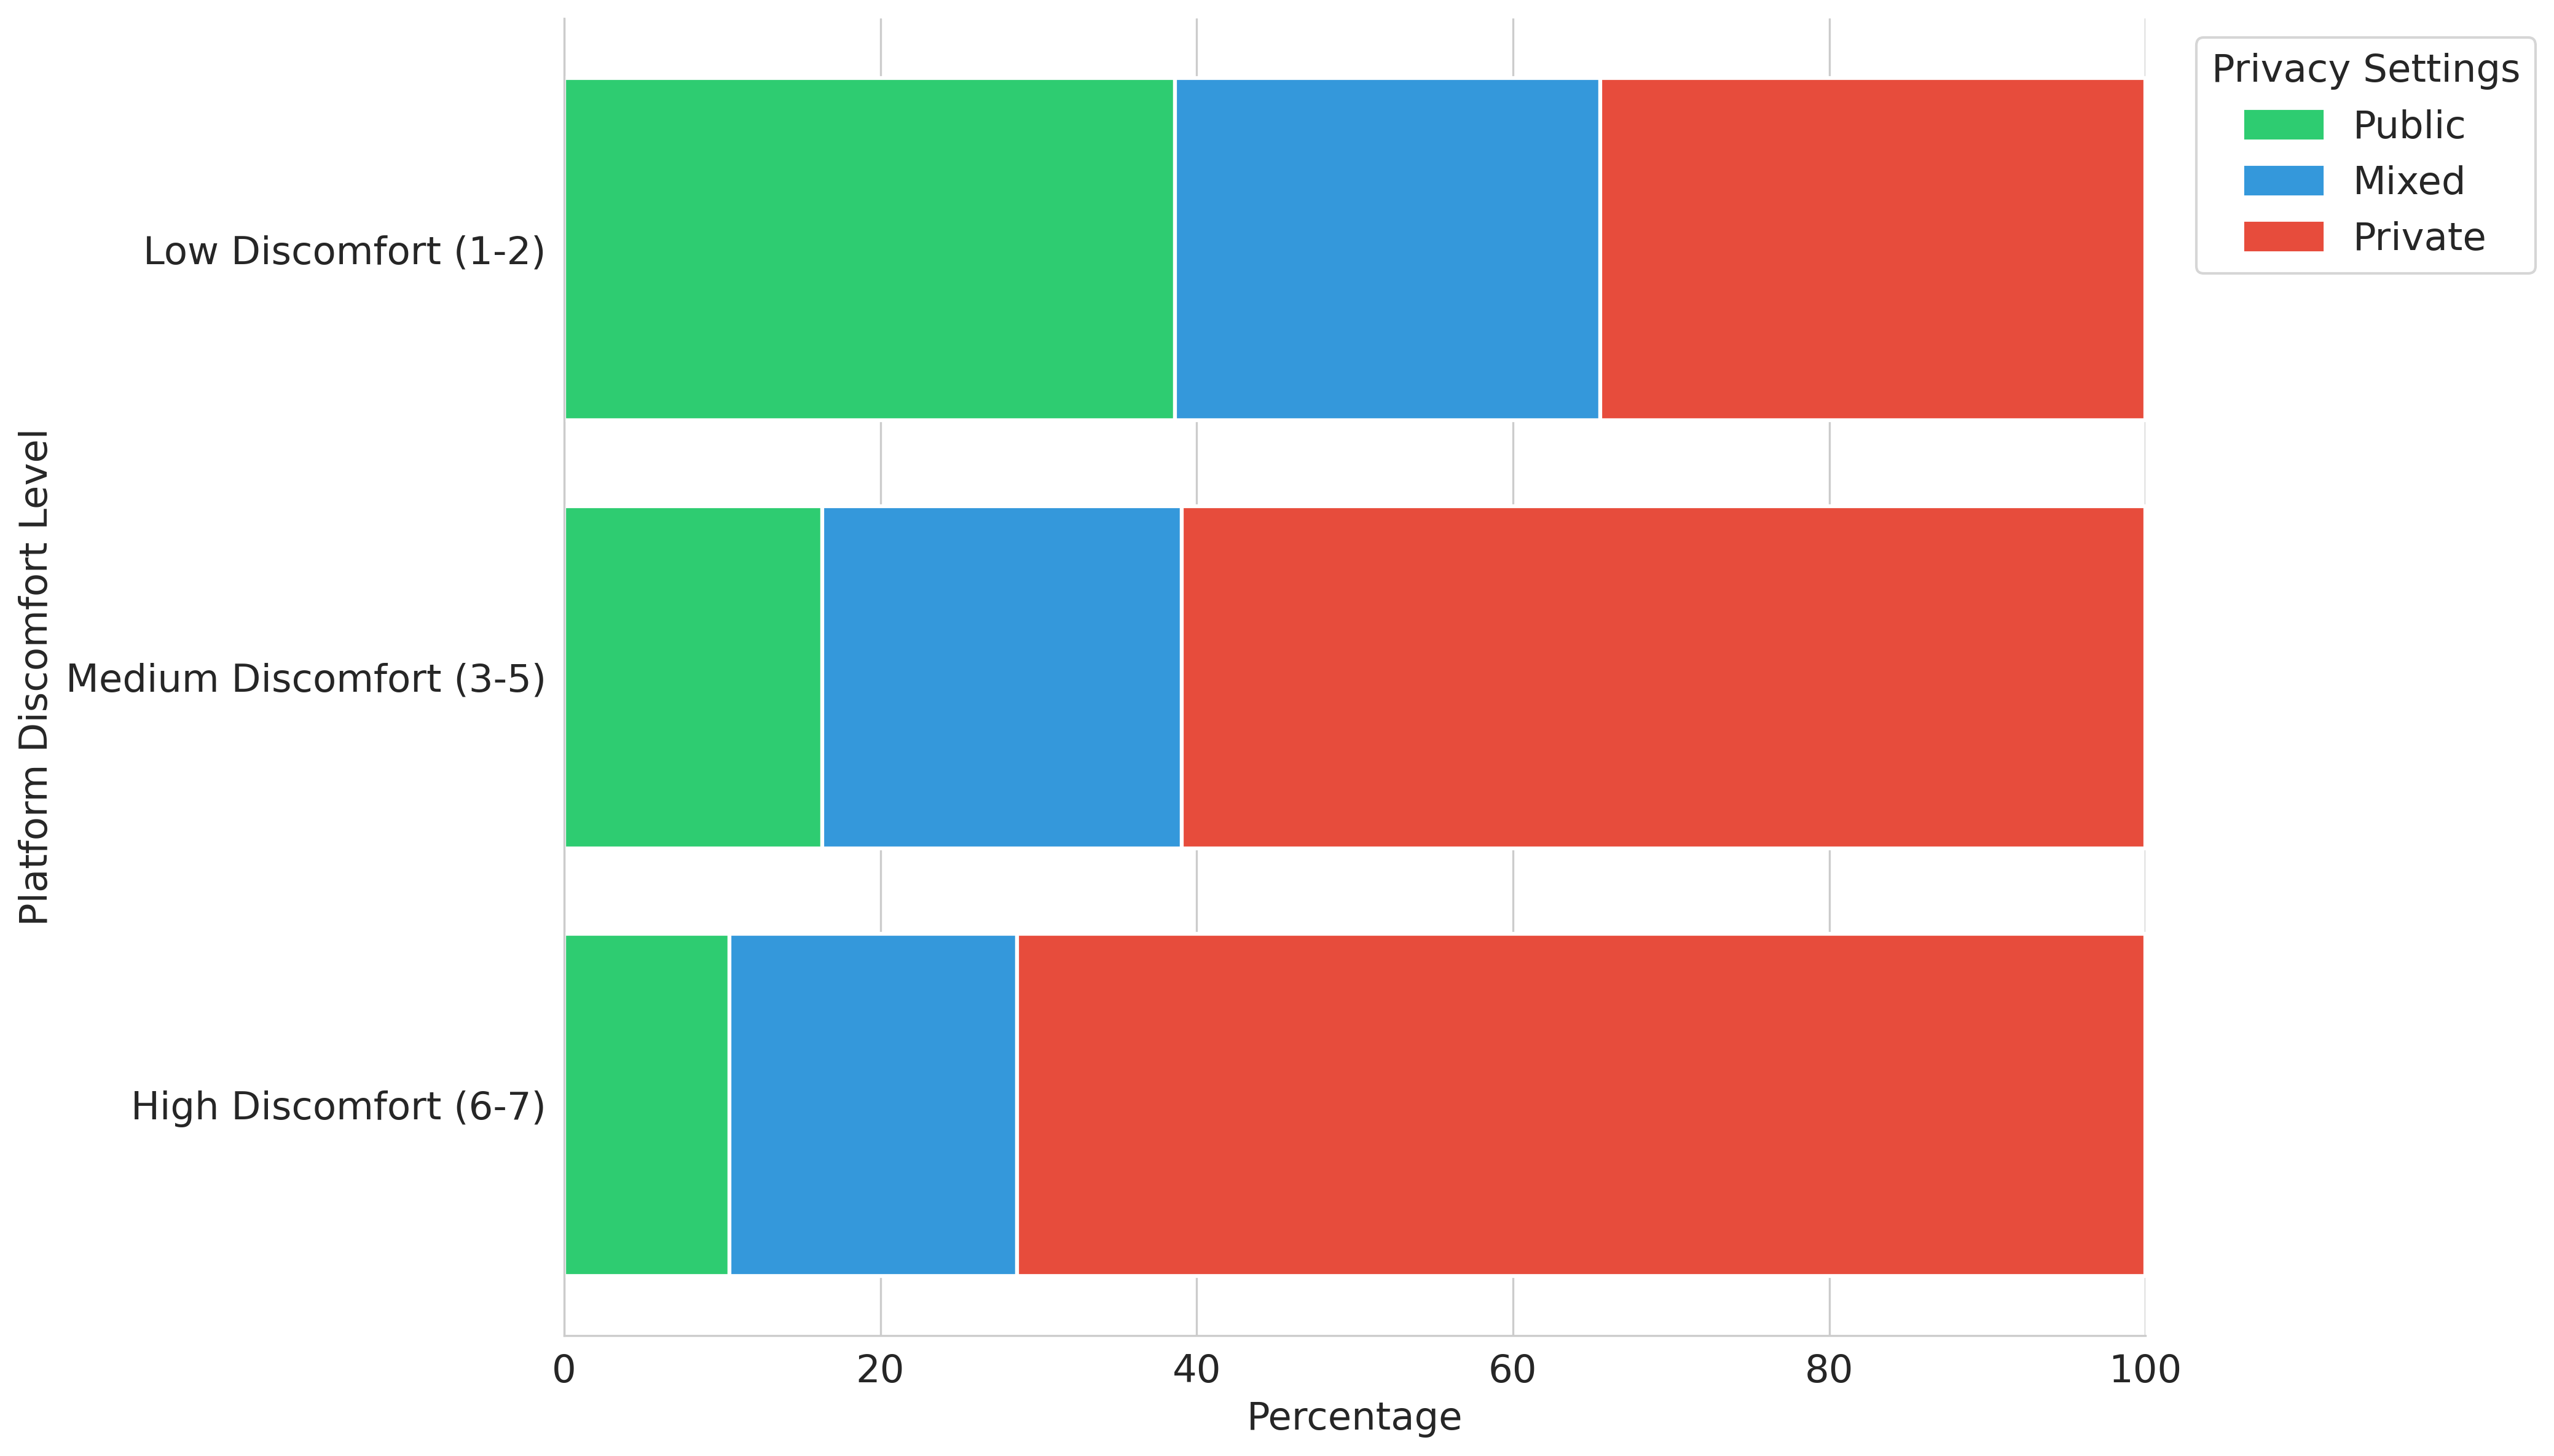

In [47]:
# Privacy settings labels
privacy_labels = {1: 'Public', 2: 'Mixed', 3: 'Private'}

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Define colors for privacy settings: Public=green, Mixed=blue, Private=red
privacy_colors = {1: '#2ecc71', 2: '#3498db', 3: '#e74c3c'}

# Prepare data for stacked bar chart
likert_groups = ['High Discomfort (6-7)', 'Medium Discomfort (3-5)', 'Low Discomfort (1-2)']
y_positions = [0, 1, 2]

for group_idx, group_name in enumerate(likert_groups):
    group_data = df_clean[df_clean['Likert_Group'] == group_name]
    total = len(group_data)

    if total == 0:
        continue

    # Get counts for each privacy setting
    privacy_counts = group_data['TP_Social'].value_counts().sort_index()

    # Calculate percentages for each privacy setting
    percentages = []
    for privacy_val in [1, 2, 3]:  # Public, Mixed, Private
        count = privacy_counts.get(privacy_val, 0)
        pct = (count / total * 100) if total > 0 else 0
        percentages.append(pct)

    # Create stacked bars
    left = 0
    for privacy_val, pct in zip([1, 2, 3], percentages):
        if pct > 0:
            ax.barh(y_positions[group_idx], pct, left=left,
                   color=privacy_colors[privacy_val],
                   edgecolor='white', linewidth=1.5)

            left += pct

# Formatting
ax.set_yticks(y_positions)
ax.set_yticklabels(likert_groups, fontsize=15)
ax.set_xlabel('Percentage', fontsize=15)
ax.set_xlim(0, 100)
ax.set_ylabel('Platform Discomfort Level', fontsize=15)

# Increase tick label size
ax.tick_params(axis='both', labelsize=15)

# Add legend with privacy settings
legend_labels = ['Public', 'Mixed', 'Private']
legend_handles = [plt.Rectangle((0,0),1,1, color=privacy_colors[i+1]) for i in range(3)]
ax.legend(legend_handles, legend_labels,
         title='Privacy Settings',
         title_fontsize=15,
         bbox_to_anchor=(1.02, 1), loc='upper left',
         frameon=True, fontsize=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

In [48]:
# loooking at confoundings with use frequency and number of platforms used
# compute use frequency:
# TP_Month_numeric: 8=More than once/day ... 1=No social media
dd = df_all[[
    "TP_Social","TP_Platform","TP_Month_numeric",
    "TP_Platforms_twitter","TP_Platforms_instagram",
    "TP_Platforms_facebook","TP_Platforms_tiktok","TP_Platforms_other"
]].dropna().copy()

dd["privacy"] = dd["TP_Social"].astype(int)
dd["platform_discomfort"] = dd["TP_Platform"].astype(int)
dd = dd[dd["privacy"].isin([1,2,3]) & dd["platform_discomfort"].between(1,7)].copy()

# platform indicators -> 0/1, breadth
Xbins = ["TP_Platforms_twitter","TP_Platforms_instagram","TP_Platforms_facebook","TP_Platforms_tiktok","TP_Platforms_other"]
for c in Xbins:
    dd[c] = (dd[c].astype(int) > 0).astype(int)
dd["n_platforms"] = dd[Xbins].sum(axis=1)

# fit adjusted ordered logit
mod_adj = OrderedModel(
    endog=dd["privacy"],
    exog=dd[["platform_discomfort","TP_Month_numeric","n_platforms"]],
    distr="logit"
)
res_adj = mod_adj.fit(method="bfgs", disp=False)
print(res_adj.summary())

# pretty Odds Ratio table
ci = res_adj.conf_int()
or_tbl = pd.DataFrame({
    "OR":   np.exp(res_adj.params),
    "CI_lo": np.exp(ci[0]),
    "CI_hi": np.exp(ci[1]),
}).loc[["platform_discomfort","TP_Month_numeric","n_platforms"]].round(3)
print("\nAdjusted odds ratios:\n", or_tbl)


                             OrderedModel Results                             
Dep. Variable:                privacy   Log-Likelihood:                -2436.6
Model:                   OrderedModel   AIC:                             4883.
Method:            Maximum Likelihood   BIC:                             4913.
Date:                Sat, 09 May 2026                                         
Time:                        13:11:44                                         
No. Observations:                2747                                         
Df Residuals:                    2742                                         
Df Model:                           3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
platform_discomfort     0.2885      0.026     11.144      0.000       0.238       0.339
TP_Month_numeric       -0